# SIR Epidemic Simulation on a Scale-Free Network

This notebook implements an **SIR** (Susceptible–Infected–Recovered) epidemic model on a scale-free network to explore how disease dynamics are shaped by network topology and public health interventions.

In [2]:
# Required Packages 
import networkx as nx
import random as rd
import numpy as np
import matplotlib.pyplot as plt

# Define global figure parameters
%matplotlib inline
plt.rcParams.update({'font.size': 15})
plt.rcParams['figure.figsize'] = [9, 5] 

In [3]:
def make_sir_model(population=400):
    """
    Make a scale-free network with 400 nodes by default.
    One random node is marked as infected (patient zero) ('state'='I'),
    all other nodes are marked as suceptible ('state'='S') 
    No node is vaccinated ('vaccinated'=False).

    Parameters
    ---------
    population: size of model
    
    Returns
    -------
    networkx model
    """

    # create a scale-free network
    model = nx.barabasi_albert_graph(population, 6)

    # Initially all nodes are set to the S (susceptible) state 
    # the infection duration is set to 0
    # all nodes are unvaccinated
    for n in model.nodes:
        model.nodes[n]['state'] = 'S'       
        model.nodes[n]['duration'] = 0
        model.nodes[n]['vaccinated'] = False

    # A node is randomly selected to become the first infected node (patient 0).
    i = rd.choice(list(model.nodes))
    model.nodes[i]['state'] = 'I'
    
    return model

In [7]:
# using the function
model = make_sir_model()

In [8]:
model.nodes

NodeView((0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 

In [9]:
# accessing the node properties
model.nodes[1]

{'state': 'S', 'duration': 0, 'vaccinated': False}

In [10]:
def count_nodes_with_status(model, state):
    """
    This functions counts the number of nodes with a specified state
    
    Parameters
    ---------
    state: the state that we want to count (e.g. 'S', 'I', 'R')

    Returns
    -------
    count: number of nodes with the specified state
    """
    count = 0
    for n in model.nodes:
        if model.nodes[n]['state'] == state:
            count += 1
    return count

In [13]:
count_nodes_with_status(model, "R")

0

In [14]:
def run_sir_model(model, 
                  infection_probability=0.02,
                  infection_probability_vax=0.005,
                  duration=14,
                  days=120):
    """
    Simulate an SIR epidemic on a network.

    Parameters
    ----------
    model : networkx.Graph
        Network with node attributes 'state' (S/I/R), 'duration' (int),
        and 'vaccinated' (bool).
    infection_probability : float
        Daily probability of infecting an unvaccinated susceptible neighbor.
    infection_probability_vax : float
        Daily probability of infecting a vaccinated susceptible neighbor.
    duration : int
        Number of days before an infected node recovers.
    days : int
        Number of days to simulate.

    Returns
    -------
    tuple[list, list, list]
        Daily counts of susceptible, infected, and recovered nodes (sim_S, sim_I, sim_R).
    """ 
    # initiate empty lists to store the number of infected, susceptible 
    # and recovered individuals each day
    sim_S, sim_I, sim_R = [], [], []

    for day in range(days):
        # for each day we count the number of nodes in each state 
        sim_S.append(count_nodes_with_status(model, "S"))
        sim_I.append(count_nodes_with_status(model, "I"))
        sim_R.append(count_nodes_with_status(model, "R"))
        
        infected_nodes = [n for n in model.nodes if model.nodes[n]['state'] == 'I']
        
        for n in infected_nodes:
            model.nodes[n]['duration'] += 1

            # some infected nodes recover 
            if model.nodes[n]['duration'] >= duration:
                model.nodes[n]['state'] = 'R'
                
            # those that are still infectious can infect their susceptible neighbours
            else:
                for nb in model.neighbors(n):
                    if model.nodes[nb]['state'] != 'S':
                        continue
                    p = infection_probability_vax if model.nodes[nb]['vaccinated'] else infection_probability
                    if rd.random() < p:
                        model.nodes[nb]['state'] = 'I'

    return sim_S, sim_I, sim_R

In [15]:
sim_S, sim_I, sim_R = run_sir_model(model)

In [18]:
# Plot the results
def plot_results(sim_S, sim_I, sim_R):
    plt.plot(range(len(sim_S)),sim_S,color="blue",label="S")
    plt.plot(range(len(sim_I)),sim_I,color="red",label="I")
    plt.plot(range(len(sim_R)),sim_R,color="green",label="R")
    plt.ylabel("Number of Individuals")
    plt.xlabel("Days")

Peak number of infected individuals 243
Mean day of the peak 29


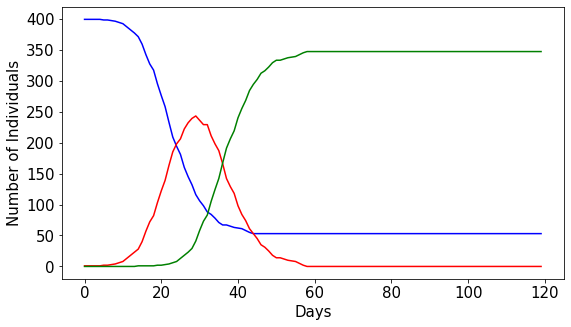

In [24]:
# run the simulation
model = make_sir_model()
sim_S, sim_I, sim_R = run_sir_model(model)
plot_results(sim_S, sim_I, sim_R)

print(f"Peak number of infected individuals {max(sim_I)}")
print(f"Mean day of the peak {np.argmax(sim_I)}")

If you run the code above several times you will see that the simulation always looks a bit different. This is because we choose the first infected node randomly and the neighbours are infected with a certain probability.
To get representationve results we need to repeat the simulation many times.

## Exercise 1
Write a `for` loop that will repeat the simulations 100 times.
In each iteration you need to
1. create a new model
2. run the simulation
3. plot the results (calling `plot_results()` inside the loop will automatically overlay each curve on the same figure)
4. record the peak number of infected individuals and the day that peak occurs, then compute the mean of each across all 100 runs



<div class="alert alert-block alert-warning"> <b>NOTE:</b> Use a for loop in all subsequent exercises with at least 100 iterations. </div>

## Exercise 2 - flatten the curve
Consider interventions such as widespread mask use, physical distancing, or treatments that shorten the infectious period. Model these by adjusting the parameters (without modifying `run_sir_model` function):
* Describe which parameters corresnpond to the different interventions
* Try a few different values to see how the average peak value changes
* Optionally make a plot where x-axis is the parameter of your choice and y-axis is the average peak

Note: do not change the function `run_sir_model`, only the parameters

## Exercise 3 - effect of random vaccination

Write a function `vaccinate_random_nodes`.
The funtion should take the networkx `model` and `fraction_to_vaccinate` (float) as arguments. 
It should randomly select nodes and change the attribute `'vaccinated'` to `True`. The number of vaccinated nodes is calculated from the`fraction_to_vaccinate` parameter.

Hint: use `rd.sample` to select random nodes. Then use a `for` loop to change the vaccination state to True for these nodes.

Run the model simulations 100 times as in exercise 2 but insert the function `vaccinate_random_nodes` after you create the model.

## Exercise 4 - effect of targeted vaccination

Instead of vaccinating randomly, we can vaccinate highly connected individuals (nodes with a high degree).
Create a function `vaccinate_high_degree_nodes`.
The funtion should take the `model` and `fraction_to_vaccinate` as arguments. 
The function should vaccinate (= change the attribute `'vaccinated'` to `True`) the specified fraction of population (`fraction_to_vaccinate`) with the highest degrees.

Hint: use `sorted(dict1, key=dict1.get, reverse=True)` with the degree dictionary to sort the nodes accodring to their degree.

Run the model simulations 100 times as in exercise 2 but insert the function `vaccinate_high_degree_nodes` after you create the model.


## Exercise 5
What fraction of population needs to be vaccinated to reduce the peak by half? Which vaccination strategy is better?
How does the result change if you change `infection_probability_vax`? Try a few different values.

## Exercise 6
**How could we make our model more realistic?**
Give 3 suggestions. Describe how you would implement it (e.g. 'the effect of X could be modeled by adding a new variable / node state / condition / different networks structure ... that would affect the infection_probability / infection duration / network structure / ...')

Optionally, implement the code.
